## pandas:
### freeCodeCamp Survey 2016

In [1]:
# download data
! curl https://raw.githubusercontent.com/freeCodeCamp/2016-new-coder-survey/refs/heads/master/clean-data/2016-FCC-New-Coders-Survey-Data.csv -o fcc-new-coder-survey-2016.csv

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
 52  9.59M  52  5.08M   0      0  5.04M      0   00:01   00:01          5.06M
100  9.59M 100  9.59M   0      0  5.30M      0   00:01   00:01          5.06M
100  9.59M 100  9.59M   0      0  5.30M      0   00:01   00:01          5.06M
100  9.59M 100  9.59M   0      0  5.30M      0   00:01   00:01          5.06M


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
df = pd.read_csv('fcc-new-coder-survey-2016.csv')

C:\Users\ggyuh\AppData\Local\Temp\ipykernel_17136\4068250882.py:1: DtypeWarning: Columns (0: CodeEventOther, 1: JobRoleInterestOther) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('fcc-new-coder-survey-2016.csv')


In [4]:
type(df)

pandas.DataFrame

In [5]:
# df
# df.columns
# df.index
# df.dtypes

# df.info()
df.head()# 제일 앞 5개
df.tail()#제일 끝 5개
df.sample(5)

,Age,AttendedBootcamp,BootcampFinish,BootcampFullJobAfter,BootcampLoanYesNo,BootcampMonthsAgo,BootcampName,BootcampPostSalary,BootcampRecommend,ChildrenNumber,...,ResourceSoloLearn,ResourceStackOverflow,ResourceTreehouse,ResourceUdacity,ResourceUdemy,ResourceW3Schools,ResourceYouTube,SchoolDegree,SchoolMajor,StudentDebtOwe
5909,26.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.0,1.0,NaN,NaN,bachelor's degree,Social Work,12000.0
11355,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13748,32.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"trade, technical, or vocational training",NaN,NaN
10743,29.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.0,1.0,NaN,NaN,"some college credit, no degree",NaN,NaN
5419,31.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,"trade, technical, or vocational training",NaN,NaN


In [6]:
# language = df.LanguageAtHome
language = df["LanguageAtHome"]
type(language)
language.unique()

<StringArray>
[                  'English',                     'Khmer',
          'Mandarin Chinese',                    'Telugu',
                   'Bengali',                   'Russian',
            'Serbo-Croatian',                     'Hindi',
                   'Spanish',                'Portuguese',
 ...
 'Wu (Shanghainese) Chinese',                     'Wolof',
                   'Quechua',                     'Irish',
                    'Divehi',                     'Welsh',
                  'Acehnese',                   'Sylheti',
               'Eastern Min',                 'Sundanese']
Length: 149, dtype: str

In [7]:
columns = df[["LanguageAtHome","CountryLive"]]
type(columns)
columns

,LanguageAtHome,CountryLive
0,English,United States of America
1,English,United States of America
2,English,United States of America
3,English,United States of America
4,Khmer,United States of America
...,...,...
15615,English,United States of America
15616,English,Canada
15617,English,United States of America
15618,English,Canada


## Analysis wit plots

Text(0.5, 1.0, 'Age Distribution')

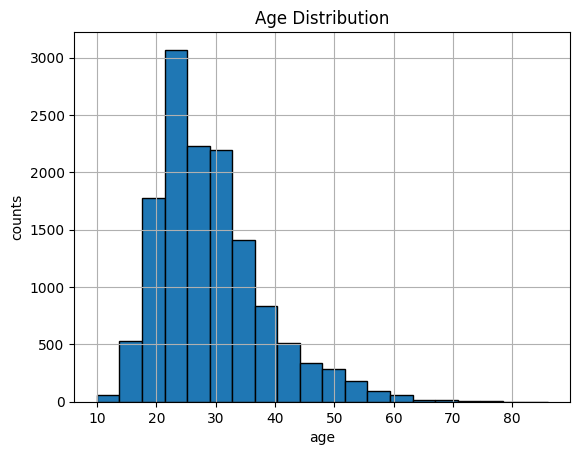

In [11]:
ages = df["Age"]
# ages.hist(bins=20)
ax = ages.hist(bins=20,edgecolor='k')
ax.set(xlabel='age',ylabel='counts')
ax.set_title("Age Distribution")

Text(0.5, 1.0, 'Income Distribution')

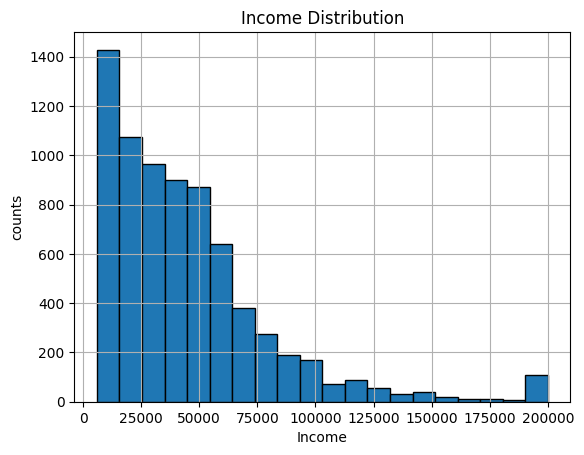

In [14]:
a = df["Income"]
# ages.hist(bins=20)
ax1 = a.hist(bins=20,edgecolor='k')
ax1.set(xlabel='Income',ylabel='counts')
ax1.set_title("Income Distribution")

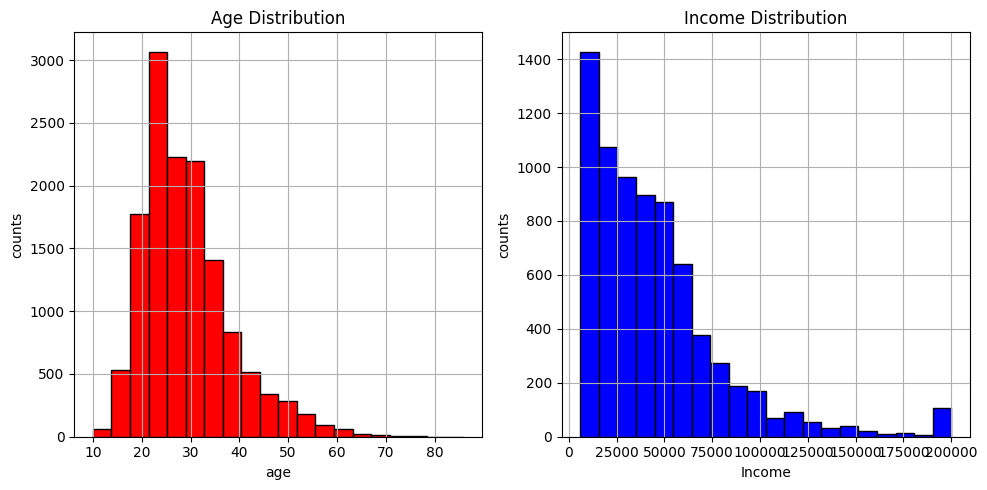

In [18]:
fig, axes = plt.subplots(1,2,figsize=(10,5))
ax = ages.hist(ax = axes[0], bins=20,edgecolor='k',color='red')
ax.set(xlabel='age',ylabel='counts')
ax.set_title("Age Distribution")
ax1 = a.hist(ax=axes[1],bins=20,edgecolor='k',color='blue')
ax1.set(xlabel='Income',ylabel='counts')
ax1.set_title("Income Distribution")
fig.tight_layout()

## Sorting and Filtering

In [29]:
# help(df.sort_values)
df_sorted_by_age = df.sort_values(by="Age",ascending=True)
# df_sorted_by_age
# df

In [32]:
df_sorted = df.sort_values(by=["Age","HoursLearning"],ascending=[True,True])
df_sorted[["Age","HoursLearning"]]


,Age,HoursLearning
7419,10.0,8.0
7341,10.0,28.0
3170,11.0,0.0
1594,11.0,4.0
1020,11.0,5.0
...,...,...
11743,NaN,NaN
11949,NaN,NaN
12072,NaN,NaN
14981,NaN,NaN


In [33]:
#filtering
df["Gender"].unique()

<StringArray>
['male', 'female', nan, 'genderqueer', 'trans', 'agender']
Length: 6, dtype: str

In [36]:
females = df["Gender"] == "female"
# df[females]

In [39]:
#Q: what percentage of females?
(len(df[females])/len(df))*100

18.181818181818183

In [40]:
males = df["Gender"] == "male"
(len(df[males])/len(df)) * 100

68.92445582586427

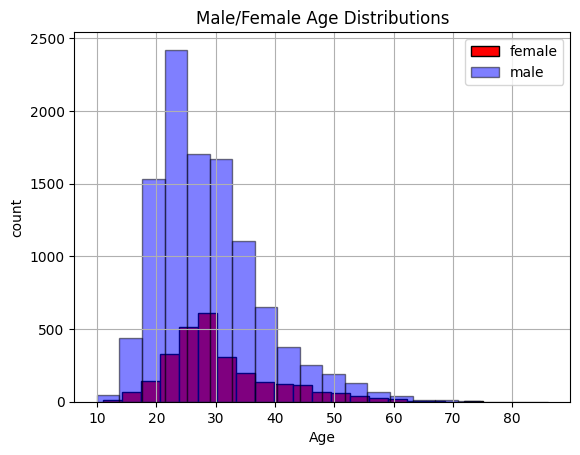

In [53]:
df_male = df[df["Gender"] == "male"]
df_female = df[df["Gender"] == "female"]

# fig, axes = plt.subplots(1,2,figsize=(8,4))
# df_female["Age"].hist(ax = axes[0],bins=20,color='blue',edgecolor='k')
# df_male["Age"].hist(ax = axes[1],bins=20,color='red',edgecolor='k')

fig, ax = plt.subplots()
df_female['Age'].hist(ax=ax,bins=20,color='r',edgecolor='k',label = 'female')
df_male['Age'].hist(ax=ax,bins=20,color='b',edgecolor='k',alpha = 0.5,label = 'male')
ax.set(xlabel='Age',ylabel='count')
ax.set_title("Male/Female Age Distributions")
ax.legend()

## Selecting rows and columns

In [54]:
df_test = pd.DataFrame(np.arange(12).reshape((4,3)),
             columns= ['a','b','c'],
             index=['A','B','C','D'])

df_test

,a,b,c
A,0,1,2
B,3,4,5
C,6,7,8
D,9,10,11


In [59]:
# df_test['a']
# df_test[['a','c']]
# df_test.loc['C',['a','c']]
df_test.iloc[:2,1:]

,b,c
A,1,2
B,4,5


In [62]:
person2000 = df.iloc[2000]
person2000

Age                                               34.0
AttendedBootcamp                                   1.0
BootcampFinish                                     1.0
BootcampFullJobAfter                               0.0
BootcampLoanYesNo                                  0.0
                                     ...              
ResourceW3Schools                                  NaN
ResourceYouTube                                    NaN
SchoolDegree            some college credit, no degree
SchoolMajor                                        NaN
StudentDebtOwe                                     NaN
Name: 2000, Length: 113, dtype: object

## Statistics

In [70]:
df["HoursLearning"].mean()
df["HoursLearning"].median()
df["HoursLearning"].quantile(1)
df["HoursLearning"].describe()

count    14942.000000
mean        15.323317
std         14.274867
min          0.000000
25%          5.000000
50%         10.000000
75%         20.000000
max        100.000000
Name: HoursLearning, dtype: float64

<Axes: xlabel='Gender'>

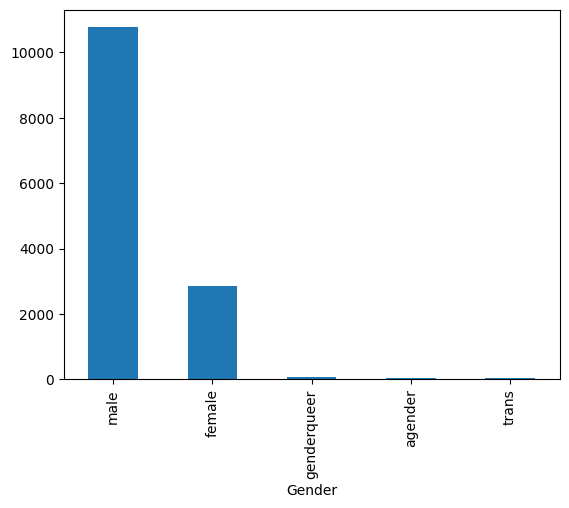

In [74]:
df["Gender"].unique()
gender_count = df["Gender"].value_counts()
# gender_count.plot(kind='pie')
gender_count.plot(kind='bar')